# L3b Advanced: Bootstrap Uncertainty in Lattice Calibration

The required L3b example produces one estimate of the binomial-lattice parameters $(u,d,p)$. Those values come from a finite historical sample, so another sample would give different estimates. This notebook measures that uncertainty and carries it into two lattice forecasts.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Calibrate:__ Estimate the up factor, down factor, and up-move probability from a historical growth-rate sample. Treat the result as a point estimate produced by one sample rather than a fixed property of the asset.
> * __Bootstrap:__ Build uncertainty intervals for calibrated parameters by resampling the historical data under a stated resampling rule. Propagate that parameter uncertainty into the expected terminal price and the probability that the terminal price exceeds its starting value.
> * __Validate:__ Compare a model estimated on one sample against a later sample it never saw. State what such a comparison establishes about sampling error and what it leaves untested about model structure.

The bootstrap measures sampling uncertainty under a chosen resampling rule. It does not prove that the fixed lattice is the correct model.

Let's get started!
___

## Setup, Data, and Prerequisites

We use the course market dataset and the same real-world estimator as the required L3b example.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl"));

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads the course toolkit [VLQuantitativeFinancePackage.jl](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl) together with the [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Distributions.jl](https://juliastats.org/Distributions.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), [Random](https://docs.julialang.org/en/v1/stdlib/Random/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), and [StatsBase.jl](https://juliastats.org/StatsBase.jl/stable/) packages. There are no local source files beyond `Include.jl` itself.

Next, we set the default plot styling and load the market dataset:

In [2]:
default(fontfamily = "Helvetica", framestyle = :box, background_color = :gray97,
    background_color_outside = :white, legend_background_color = nothing, linewidth = 2);

In [3]:
market_data = MyTrainingMarketDataSet() |> x -> x["dataset"]
ticker = "AAPL"
firm_data = market_data[ticker]
Δt = 1.0 / 252.0
growth_rates = log_growth_matrix(market_data, ticker)

DataFrame(ticker = ticker, price_observations = nrow(firm_data),
    growth_observations = length(growth_rates),
    first_date = minimum(firm_data.timestamp), last_date = maximum(firm_data.timestamp))

Row,ticker,price_observations,growth_observations,first_date,last_date
,String,Int64,Int64,DateTime,DateTime
1,AAPL,2767,2766,2014-01-03T05:00:00,2024-12-31T05:00:00


___

## Task 1: Calibrate the lattice and forecast from it

In this task, we'll estimate one set of lattice parameters from the full sample of growth rates and compute two forecasts from them. These single numbers are the starting point, and Task 2 asks how much they would move if we had drawn a different sample.

### Point calibration

The estimator averages the one-step multipliers $\exp(g_t\Delta t)$ separately over positive and negative growth observations to obtain $\widehat u$ and $\widehat d$. The estimate $\widehat p$ is the fraction of positive observations. These are historical summaries, and the method does not impose $\widehat d=1/\widehat u$.

In [4]:
estimate_parameters(R::Vector{Float64}) =
    (RealWorldBinomialProbabilityMeasure())(R; Δt = Δt)

û, d̂, p̂ = estimate_parameters(growth_rates)
@assert !isapprox(d̂, 1 / û; rtol = 1e-6)
DataFrame(parameter = ["up factor u", "down factor d", "up probability p", "reciprocal 1/u"],
    estimate = [û, d̂, p̂, 1 / û])

Row,parameter,estimate
,String,Float64
1,up factor u,1.01059
2,down factor d,0.989301
3,up probability p,0.550976
4,reciprocal 1/u,0.989516


### Two forecasts computed from the calibration

We then use the calibrated lattice to compute two forecasts: the expected terminal price and the probability that the terminal price exceeds its starting value. Both are model outputs, so uncertainty in $(u,d,p)$ creates uncertainty in both forecasts.

For a horizon of $N$ steps, let $K_N$ be the number of up moves. Then $K_N\sim\operatorname{Binomial}(N,p)$, and the terminal price after $k$ up moves is $S_{N,k}=S_0u^kd^{N-k}$. Let $S_N$ denote the random terminal price. The probability that it exceeds $S_0$ is
$$
\boxed{
P_{\mathrm{above}}:=\mathbb{P}(S_N>S_0)
=\sum_{k=0}^{N}\mathbf{1}_{\{S_0u^kd^{N-k}>S_0\}}\binom{N}{k}p^k(1-p)^{N-k}.
}
$$
Here $\mathbb{P}$ is the real-world probability rule defined by $p$, and $\mathbf{1}$ equals one when its condition holds and zero otherwise. For this notebook, $P_{\mathrm{above}}$ is also the probability of profit for one share bought at $S_0$ and sold after $N$ steps with no fees, bid--ask spread, slippage, dividends, or benchmark growth. We use the narrower label because [L4a](../../../../week-4/L4a/CHEME-5660-L4a-Lecture-LatticeModel-TradeRule-Fall-2026.ipynb) develops the general NPV-based probability-of-profit calculation.

In [5]:
function terminal_forecast(S₀::Float64, u::Float64, d::Float64, p::Float64, h::Int)
    k = collect(0:h)
    prices = S₀ .* u .^ k .* d .^ (h .- k)
    probabilities = pdf.(Binomial(h, p), k)
    return (expected_terminal_price = sum(prices .* probabilities),
        probability_above_start = sum(probabilities[prices .> S₀]))
end

S₀ = Float64(last(firm_data.volume_weighted_average_price))
horizon = 21
point_forecast = terminal_forecast(S₀, û, d̂, p̂, horizon)
DataFrame(ticker = ticker, starting_price = S₀, horizon_trading_days = horizon,
    expected_terminal_price = point_forecast.expected_terminal_price,
    probability_above_start = point_forecast.probability_above_start)

Row,ticker,starting_price,horizon_trading_days,expected_terminal_price,probability_above_start
,String,Float64,Int64,Float64,Float64
1,AAPL,250.735,21,256.232,0.682263


___

## Task 2: Bootstrap the calibration

In this task, we'll resample the growth-rate series, recalibrate on every resample, and carry the resulting spread through to the forecasts. We resample two ways, drawing single observations and drawing consecutive blocks, because the independent draw assumes away any dependence between consecutive days.

### Resample and recalibrate

We draw 500 resamples. The independent version runs first, and the block version comes at the end of this task.

An independent bootstrap draws observations with replacement until the resample has the original length. A circular moving-block bootstrap instead draws short consecutive runs and retains some local dependence inside each block.

In [6]:
function circular_block_sample(rng, R::Vector{Float64}, block_length::Int)
    draw = Float64[]
    while length(draw) < length(R)
        start = rand(rng, 1:length(R))
        append!(draw, [R[mod1(start + j - 1, length(R))] for j in 1:block_length])
    end
    return draw[1:length(R)]
end

function bootstrap_calibration(R::Vector{Float64}; B::Int, block_length::Int,
    seed::Int, S₀::Float64, horizon::Int)
    rng = MersenneTwister(seed)
    rows = NamedTuple[]
    for sample_index in 1:B
        draw = block_length == 1 ? R[rand(rng, 1:length(R), length(R))] :
            circular_block_sample(rng, R, block_length)
        u, d, p = estimate_parameters(draw)
        forecast = terminal_forecast(S₀, u, d, p, horizon)
        push!(rows, (sample = sample_index, u = u, d = d, p = p,
            expected_terminal_price = forecast.expected_terminal_price,
            probability_above_start = forecast.probability_above_start))
    end
    return DataFrame(rows)
end

bootstrap_calibration (generic function with 1 method)

In [7]:
B = 500
iid_bootstrap = bootstrap_calibration(growth_rates; B = B, block_length = 1,
    seed = 5660, S₀ = S₀, horizon = horizon)

interval_row(label, point, values) = (quantity = label, point_estimate = point,
    bootstrap_mean = mean(values), lower_95 = quantile(values, 0.025),
    upper_95 = quantile(values, 0.975))

iid_intervals = DataFrame([
    interval_row("u", û, iid_bootstrap.u),
    interval_row("d", d̂, iid_bootstrap.d),
    interval_row("p", p̂, iid_bootstrap.p),
    interval_row("expected terminal price", point_forecast.expected_terminal_price, iid_bootstrap.expected_terminal_price),
    interval_row("P(S_N > S_0)", point_forecast.probability_above_start, iid_bootstrap.probability_above_start),
])
iid_intervals

Row,quantity,point_estimate,bootstrap_mean,lower_95,upper_95
,String,Float64,Float64,Float64,Float64
1,u,1.01059,1.01059,1.0101,1.01104
2,d,0.989301,0.989325,0.98873,0.989894
3,p,0.550976,0.551117,0.533623,0.569604
4,expected terminal price,256.232,256.305,253.352,259.211
5,P(S_N > S_0),0.682263,0.678407,0.601202,0.741747


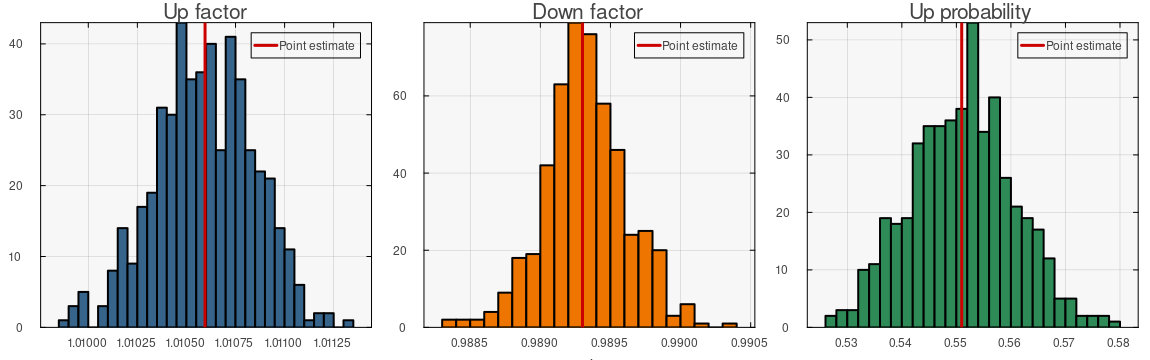

In [8]:
p_u = histogram(iid_bootstrap.u; bins = 30, color = :steelblue4, label = "", xlabel = "u", title = "Up factor")
vline!(p_u, [û]; color = :red3, linewidth = 3, label = "Point estimate")
p_d = histogram(iid_bootstrap.d; bins = 30, color = :darkorange2, label = "", xlabel = "d", title = "Down factor")
vline!(p_d, [d̂]; color = :red3, linewidth = 3, label = "Point estimate")
p_p = histogram(iid_bootstrap.p; bins = 30, color = :seagreen4, label = "", xlabel = "p", title = "Up probability")
vline!(p_p, [p̂]; color = :red3, linewidth = 3, label = "Point estimate")
plot(p_u, p_d, p_p; layout = (1, 3), size = (1150, 360))

### Parameter uncertainty becomes forecast uncertainty

Next, we plot the two forecasts from every bootstrap sample against each other. The spread of that cloud is the forecast uncertainty hidden by a single point calibration.

Each bootstrap sample produces a different lattice and therefore different forecast values. The relationship is not one-to-one because $u$, $d$, and $p$ move together across resamples.

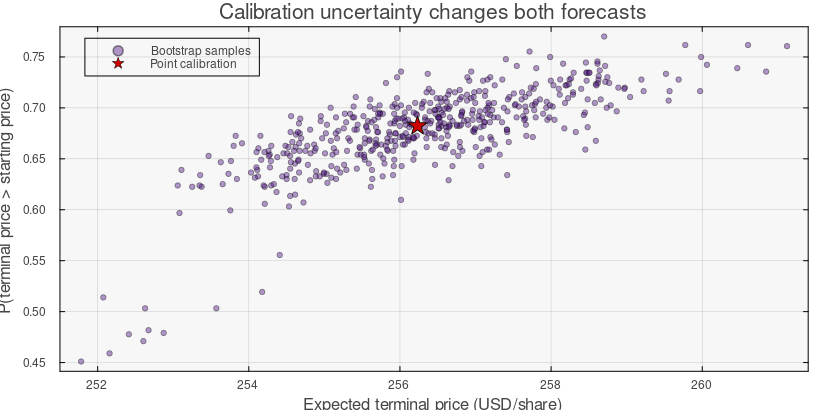

In [9]:
scatter(iid_bootstrap.expected_terminal_price, iid_bootstrap.probability_above_start;
    markersize = 3, markeralpha = 0.45, color = :purple4, label = "Bootstrap samples",
    xlabel = "Expected terminal price (USD/share)", ylabel = "P(terminal price > starting price)",
    title = "Calibration uncertainty changes both forecasts", size = (820, 410))
scatter!([point_forecast.expected_terminal_price], [point_forecast.probability_above_start];
    marker = :star5, markersize = 10, color = :red3, label = "Point calibration")

### Compare independent and block resampling

Finally, we rerun the bootstrap with 10-day blocks and compare the interval widths against the independent case. The comparison shows whether keeping short runs of days intact changes the answer.

We use 10-day blocks as a declared sensitivity case, not as a uniquely correct choice. The table compares the widths of the central 95% bootstrap intervals.

In [10]:
block_bootstrap = bootstrap_calibration(growth_rates; B = B, block_length = 10,
    seed = 5661, S₀ = S₀, horizon = horizon)
interval_width(values) = quantile(values, 0.975) - quantile(values, 0.025)

resampling_comparison = DataFrame(
    quantity = ["u", "d", "p", "expected terminal price", "P(S_N > S_0)"],
    iid_interval_width = interval_width.([iid_bootstrap.u, iid_bootstrap.d, iid_bootstrap.p,
        iid_bootstrap.expected_terminal_price, iid_bootstrap.probability_above_start]),
    block_interval_width = interval_width.([block_bootstrap.u, block_bootstrap.d, block_bootstrap.p,
        block_bootstrap.expected_terminal_price, block_bootstrap.probability_above_start]),
)
resampling_comparison

Row,quantity,iid_interval_width,block_interval_width
,String,Float64,Float64
1,u,0.000939809,0.00124471
2,d,0.00116444,0.00158983
3,p,0.0359816,0.0412148
4,expected terminal price,5.85858,6.62081
5,P(S_N > S_0),0.140545,0.17204


___

## Task 3: Check the model against a holdout

In this task, we'll calibrate on the first 80% of the observations and compare the model's one-step summaries against the last 20%.

### A simple holdout check

Bootstrap intervals describe variation around the calibration sample. Validation asks a different question.

In [11]:
split_index = floor(Int, 0.80 * length(growth_rates))
calibration_rates = growth_rates[1:split_index]
holdout_rates = growth_rates[(split_index + 1):end]
u_train, d_train, p_train = estimate_parameters(calibration_rates)

calibration_model = [p_train, p_train * u_train + (1 - p_train) * d_train]
holdout_sample = [count(>(0.0), holdout_rates) / length(holdout_rates),
    mean(exp.(holdout_rates .* Δt))]
holdout_check = DataFrame(
    statistic = ["up frequency", "mean one-step multiplier"],
    calibration_model = calibration_model,
    holdout_sample = holdout_sample,
    difference = holdout_sample .- calibration_model,
)
holdout_check

Row,statistic,calibration_model,holdout_sample,difference
,String,Float64,Float64,Float64
1,up frequency,0.551085,0.550542,-0.000543475
2,mean one-step multiplier,1.00101,1.00112,0.000110866


___

## Interpretation limits

- The intervals are conditional on the estimator and resampling rule.
- Independent and block resampling preserve different features of the data.
- A narrow interval does not establish that a two-state lattice is structurally adequate.
- The holdout comparison checks two one-step summaries, not the full price distribution.
- Changing the asset, sample period, time step, block length, or estimator can change every result.

___

## Summary

This notebook measured the sampling uncertainty in a binomial-lattice calibration and carried that uncertainty into the two forecasts computed from the fitted model.

> __Key Takeaways:__
>
> * __A calibration is an estimate:__ A historical sample yields one draw of the up factor, down factor, and up-move probability. Resampling that data shows how far those values move under a different draw.
> * __Parameter uncertainty becomes forecast uncertainty:__ Every resampled calibration produces a different expected terminal price and probability that the terminal price exceeds its starting value. Interval widths depend on the resampling rule, because independent and block resampling preserve different features of the data.
> * __Validation is separate from calibration:__ A fitted model must be checked against observations that were not used to estimate it. Passing that check is evidence the fit carries to new data, but it still does not show that a two-state lattice is structurally adequate.

A clear lattice report states the estimator, sample period, time step, uncertainty method, and validation result alongside the point estimates.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.